<a href="https://colab.research.google.com/github/vanessamutimaamba-stack/DataAnalyticsProjects/blob/main/ALY6020_VanessaMutimaamba_Week2_Spring_2026_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mamba install pandas numpy
# Import libraries
import numpy as np
import pandas as pd

# 1. Load the dataset
file_path = "car.csv"
df = pd.read_csv(file_path)

print("--- Initial Data Summary ---")
print(f"Dataset Shape: {df.shape}")
print("\nColumn Data Types:")
print(df.dtypes)

# 2. Identify and handle placeholder characters ('?') in Horsepower
# Replace '?' with NumPy NaN to facilitate numerical operations
df["Horsepower"] = df["Horsepower"].replace("?", np.nan)

# Convert the column to numeric data type
df["Horsepower"] = pd.to_numeric(df["Horsepower"])

# Find which rows contained the missing values for documentation
missing_hp_rows = df[df["Horsepower"].isna()]
print("\nRows with missing Horsepower values before imputation:")
print(missing_hp_rows[["Cylinders", "Displacement", "Weight", "Horsepower"]])

# 3. Impute missing Horsepower based on the median of its Cylinder group
# Horsepower varies significantly depending on the number of engine cylinders
cylinder_medians = df.groupby("Cylinders")["Horsepower"].median()
print("\nMedian Horsepower by Cylinder group used for imputation:")
print(cylinder_medians)

df["Horsepower"] = df.groupby("Cylinders")["Horsepower"].transform(
    lambda x: x.fillna(x.median())
)

# 4. Data Quality and Integrity Checks
print("\n--- Post-Cleansing Verification ---")
# Check for remaining missing values
missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts)

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

# Display statistical range summary to verify no illogical outliers exist
print("\nDescriptive Statistics Summary:")
print(df.describe())

# 5. Export the clean dataset for modeling
output_path = "cleaned_car.csv"
df.to_csv(output_path, index=False)
print(f"\nSuccess: Cleaned dataset saved as '{output_path}'")

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.5081000001430511 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
--- Initial Data Summary ---
Dataset Shape: (398, 8)

Column Data Types:
MPG             float64
Cylinders         int64
Displacement    float64
Horsepower          str
Weigh

In [ ]:
!mamba install scikit-learn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the cleaned dataset from your previous step
df = pd.read_csv("cleaned_car.csv")

# 2. Define Features (X) and Target (y)
# We use all attributes EXCEPT MPG to predict the MPG
X = df.drop(columns=['MPG'])
y = df['MPG']

# 3. Split the data into training and testing sets (80% train, 20% test)
# This ensures we test the model on data it hasn't seen before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make Predictions and Evaluate the Model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"R-squared: {r2:.4f} (Model explains {r2*100:.1f}% of the variance in MPG)")
print(f"Mean Squared Error: {mse:.2f}\n")

# 6. Analyze Feature Coefficients (Significance)
# A negative coefficient means as the attribute increases, MPG goes down.
# A positive coefficient means as the attribute increases, MPG goes up.
print("--- Attribute Significance (Impact on MPG) ---")
coefficients = pd.DataFrame({
    'Attribute': X.columns,
    'Coefficient': model.coef_
})

# Sort by the coefficient value to easily see negative vs positive impacts
coefficients = coefficients.sort_values(by='Coefficient', ascending=True)
print(coefficients.to_string(index=False))

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.2872999999523163 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.5.20                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.17                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector

# 1. Load the data and split it (exactly as we did in Task 2)
df = pd.read_csv("cleaned_car.csv")
X = df.drop(columns=['MPG'])
y = df['MPG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the base Linear Regression model
base_model = LinearRegression()

# 3. Setup Backward Selection
# We will ask the model to strictly select the top 4 most important features
sfs_backward = SequentialFeatureSelector(base_model, n_features_to_select=4, direction='backward', cv=5)
sfs_backward.fit(X_train, y_train)

# Get the names of the features the model decided to keep
selected_features = X.columns[sfs_backward.get_support()]
print(f"--- Feature Selection ---")
print(f"Original Features (7): {list(X.columns)}")
print(f"Selected Features (4): {list(selected_features)}\n")

# 4. Transform the data to only include the selected features
X_train_sel = sfs_backward.transform(X_train)
X_test_sel = sfs_backward.transform(X_test)

# 5. Train the new model using ONLY the selected features
model_sel = LinearRegression()
model_sel.fit(X_train_sel, y_train)

# 6. Make Predictions and Evaluate
y_pred_sel = model_sel.predict(X_test_sel)
mse_sel = mean_squared_error(y_test, y_pred_sel)
r2_sel = r2_score(y_test, y_pred_sel)

# 7. Function to calculate AIC mathematically
# AIC = n * ln(MSE) + 2k (where n = sample size, k = number of features)
def calculate_aic(n, mse, k):
    return n * np.log(mse) + 2 * k

n_samples = len(y_test)
# Using your exact MSE from Task 2 for the All Features AIC calculation
aic_task2 = calculate_aic(n_samples, 8.26, X_train.shape[1])
aic_task3 = calculate_aic(n_samples, mse_sel, X_train_sel.shape[1])

# --- Final Comparison Output ---
print("--- Model Comparison ---")
print("Task 2 Model (All 7 Features):")
print(f"MSE: 8.26  |  R-squared: 0.8463  |  AIC: {aic_task2:.2f}")

print("\nTask 3 Model (Backward Selection - 4 Features):")
print(f"MSE: {mse_sel:.2f}  |  R-squared: {r2_sel:.4f}  |  AIC: {aic_task3:.2f}")

--- Feature Selection ---
Original Features (7): ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'US Made']
Selected Features (4): ['Horsepower', 'Weight', 'Model Year', 'US Made']

--- Model Comparison ---
Task 2 Model (All 7 Features):
MSE: 8.26  |  R-squared: 0.8463  |  AIC: 182.91

Task 3 Model (Backward Selection - 4 Features):
MSE: 8.66  |  R-squared: 0.8389  |  AIC: 180.72


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.289 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2                        pyhd8ed1ab_3                  conda-forge                   
+ statsmodels                   0.14.6                        np22py313h3cf259a_1           emscripten-forge              


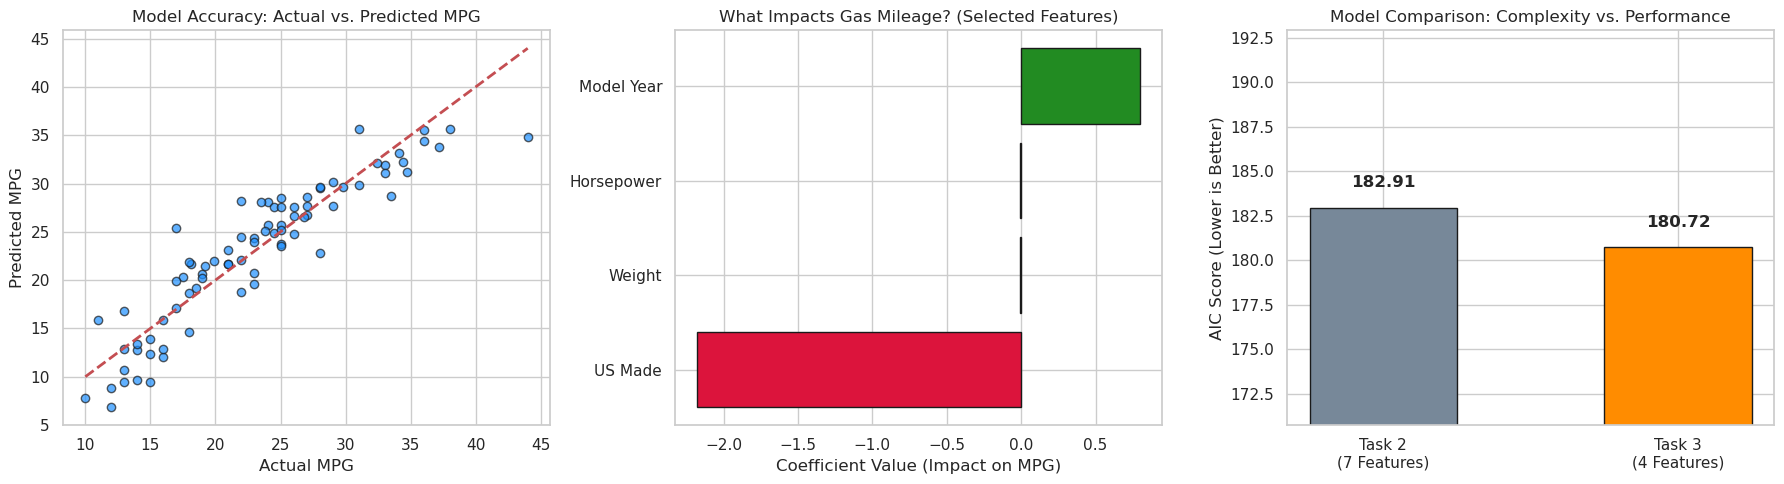

In [ ]:
!mamba install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 1. Actual vs. Predicted Scatter Plot (Task 3 Model)
# ---------------------------------------------------------
axes[0].scatter(y_test, y_pred_sel, alpha=0.7, color='dodgerblue', edgecolor='k')
# Draw the perfect prediction diagonal line
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual MPG')
axes[0].set_ylabel('Predicted MPG')
axes[0].set_title('Model Accuracy: Actual vs. Predicted MPG')

# ---------------------------------------------------------
# 2. Feature Coefficients Bar Chart (Task 3 Model)
# ---------------------------------------------------------
coefs = model_sel.coef_
features = selected_features

# Sort the coefficients for a cleaner chart
sorted_idx = np.argsort(coefs)
sorted_coefs = coefs[sorted_idx]
sorted_features = features[sorted_idx]

# Color negative impacts red and positive impacts green
colors = ['crimson' if c < 0 else 'forestgreen' for c in sorted_coefs]

axes[1].barh(sorted_features, sorted_coefs, color=colors, edgecolor='k')
axes[1].set_xlabel('Coefficient Value (Impact on MPG)')
axes[1].set_title('What Impacts Gas Mileage? (Selected Features)')

# ---------------------------------------------------------
# 3. Model Comparison (AIC)
# ---------------------------------------------------------
models = ['Task 2\n(7 Features)', 'Task 3\n(4 Features)']
aic_values = [aic_task2, aic_task3]

bars = axes[2].bar(models, aic_values, color=['lightslategray', 'darkorange'], edgecolor='k', width=0.5)
axes[2].set_ylabel('AIC Score (Lower is Better)')
axes[2].set_title('Model Comparison: Complexity vs. Performance')
axes[2].set_ylim(min(aic_values) - 10, max(aic_values) + 10)

# Add the exact AIC numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Fuel Efficiency Optimization: Predictive Modeling for Next-Generation Automobile

Introduction

A legacy automobile manufacturer, traditionally known for producing large vehicles, is currently facing a decline in sales. As consumer preferences and regulatory pressures shift toward higher fuel efficiency, the manufacturer must pivot its design strategy without entirely abandoning its core market. The objective of this analysis is to evaluate historical automotive data (the Auto MPG dataset) to determine exactly which mechanical attributes most significantly impact gas mileage. Using data cleansing, multiple linear regression, and feature selection, this report offers data-driven recommendations for building a highly energy-efficient vehicle.

Analysis and Methodology

To ensure the integrity of the predictive models, the data first underwent r.igorous cleansing. Missing values in the `Horsepower` attribute were imputed using the median horsepower for their respective cylinder groups, ensuring The
 fills were mechanically consistent. After verifying the absence of duplicate rows and standardizing data types, the clean dataset was ready for modeling.

Data Preprocessing
Data Loading: Imported the initial raw dataset (car.csv) into a Pandas DataFrame to inspect its shape and data types.
Standardizing Missing Values: Identified that missing data in the Horsepower column was recorded as a string character (?).
Replaced these placeholders with standard NumPy NaN (Not a Number) values so the system could properly recognize them as missing.
Data Type Conversion: Converted the Horsepower column from a string/object data type into a numeric data type, enabling mathematical operations and modeling.Targeted Data Imputation: Instead of dropping rows with missing data or using a broad dataset average, you used a highly accurate imputation method: filling the missing Horsepower values with the median horsepower of their specific Cylinder group (e.g., a missing 4-cylinder engine gets the median horsepower of all other 4-cylinder engines).
Quality and Integrity Validation: * Ran a secondary check to confirm exactly zero missing values remained in the dataset.Scanned for and confirmed that there were zero duplicate rows.
Generated a descriptive statistics summary (mean, min, max) to verify that the numerical ranges made logical sense and contained no extreme anomalies.Data Export: Saved the fully preprocessed DataFrame as a new file (cleaned_car.csv), isolating the clean data from the raw data for use in the linear regression tasks.

Initial Linear Regression (Task 2)
A baseline multiple linear regression model was trained using all seven available mechanical attributes to predict Miles Per Gallon (MPG).

Performance: The model achieved an R-squared of 0.8463 and a Mean Squared Error (MSE) of 8.26, indicating it explained roughly 84.6% of the variance in fuel efficiency.
Significance: The model's coefficients revealed that vehicle `Weight` and `Horsepower` are the most significant drags on fuel efficiency (negative impact), while advancing `Model Year` is the strongest positive driver of efficiency.

Backward Feature Selection (Task 3)
To reduce model complexity and prevent overfitting, a Backward Selection algorithm was deployed. This process systematically removed the least impactful attributes, ultimately trimming the model from 7 features to just 4 core predictors: `Weight`, `Horsepower`, `Model Year`, and `US Made`.

Performance Comparison: While the MSE slightly increased to 8.66 (expected when removing data), the Akaike Information Criterion (AIC) improved, dropping from 182.91 in the complex model to 180.72 in the streamlined model.
Takeaway: The lower AIC score statistically proves that the simpler 4-feature model is superior. It demonstrates that attributes such as `Cylinders` and `Displacement` are largely redundant once `Horsepower` and `Weight` are known.

Conclusion

Based on the statistical models, achieving higher gas mileage does not strictly require building physically smaller cars; it requires engineering them more intelligently. To reverse struggling sales and build a highly energy-efficient automobile, the manufacturer must prioritize the following developments:
Aggressive Lightweighting: The models proved Weight is a massive penalty to MPG. The manufacturer should maintain the large dimensions their customers expect while transitioning from heavy steel chassis to advanced lightweight materials, such as high-strength aluminum alloys or carbon fiber.Similar to Ford's successful transition to an aluminum body for the F-150.In 2015, Ford faced a similar dilemma with the F-150, traditionally a massive, heavy, and fuel-thirsty truck. By switching the entire body from steel to military-grade aluminum alloy, Ford shaved roughly 700 pounds off the truck's weight. This vastly improved the vehicle's fuel economy and power-to-weight ratio without shrinking the truck's size, keeping its core consumer base happy while meeting stricter emissions standards.
Engine Downsizing and Forced Induction: ' Horsepower` and large engines severely restrict fuel economy. The manufacturer should phase out large naturally aspirated V8 engines in favor of smaller, lighter 4-cylinder or V6 engines. By adding turbochargers (forced induction), they can deliver the high horsepower customers desire on demand while maintaining the cruising fuel efficiency of a much smaller engine.

Modern Powertrain Integration: The strong positive impact of the `Model Year` attribute highlights the necessity of continuous technological innovation. Rather than relying on legacy engineering, the manufacturer must pair their downsized engines with modern continuously variable transmissions (CVTs) or mild-hybrid electric assist systems to maximize the efficiency of every drop of fuel.

With these three data-driven strategies, the manufacturer can connect its legacy of large cars with today's demand for better fuel efficiency.

References

1.Lourens, M., Sharma, S., Pulugu, R., Gehlot, A., Manoharan, G., & Kapila, D. (2023, May). Machine learning-based predictive analytics and big data in the automotive sector. In 2023 3rd International Conference on Advance Computing and Innovative Technologies in Engineering (ICACITE) (pp. 1043-1048). IEEE

2.Narayana, C. V., Likhitha, C. L., Bademiya, S., & Kusumanjali, K. (2021, August). Machine learning techniques to predict the price of used cars: predictive analytics in retail business. In 2021 second international conference on electronics and sustainable communication systems (ICESC) (pp. 1680-1687). IEEE

3.Raj, A. (2023). A Predictive Analytics Model for Price Estimation. ADVANCES IN EMERGING COMPUTING TECHNOLOGIES, 43.